Embeddings : (2409, 64)
Labels     : (2409, 14)  (14 classes)
Train/Val/Test split: 1445 / 481 / 483
k=2  HL=0.2893  F1=0.4904  t=1.7s
k=3  HL=0.2489  F1=0.6058  t=1.8s
k=4  HL=0.2243  F1=0.6305  t=2.0s
k=5  HL=0.2203  F1=0.6355  t=2.3s
k=6  HL=0.2152  F1=0.6407  t=2.6s
k=7  HL=0.2122  F1=0.6335  t=2.9s


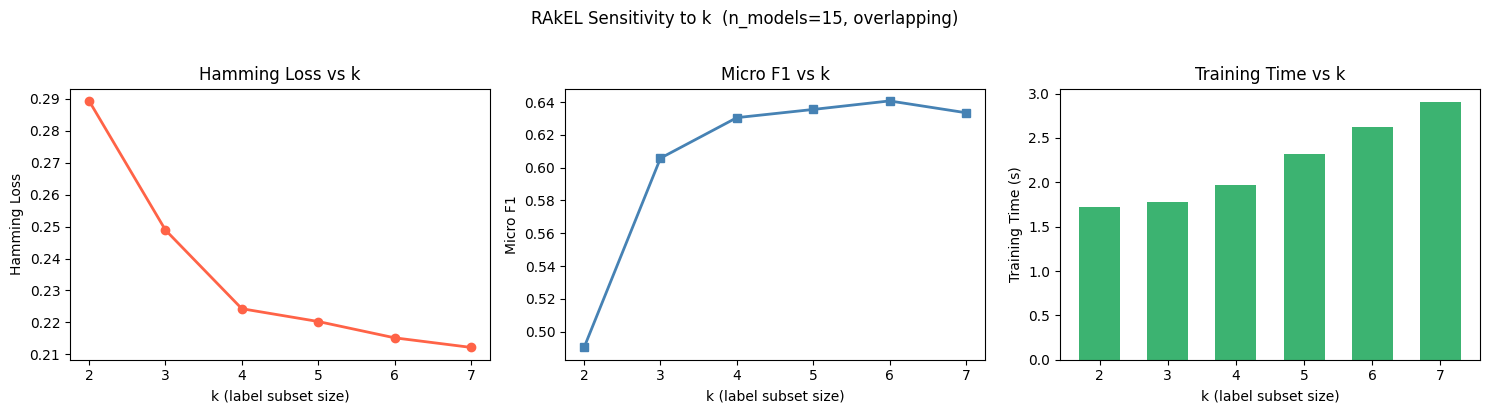

n_models=  2  HL=0.3172  F1=0.1326
n_models=  5  HL=0.3086  F1=0.4321
n_models= 10  HL=0.2635  F1=0.5854
n_models= 15  HL=0.2489  F1=0.6058
n_models= 20  HL=0.2462  F1=0.6076
n_models= 30  HL=0.2274  F1=0.6238
n_models= 40  HL=0.2187  F1=0.6338


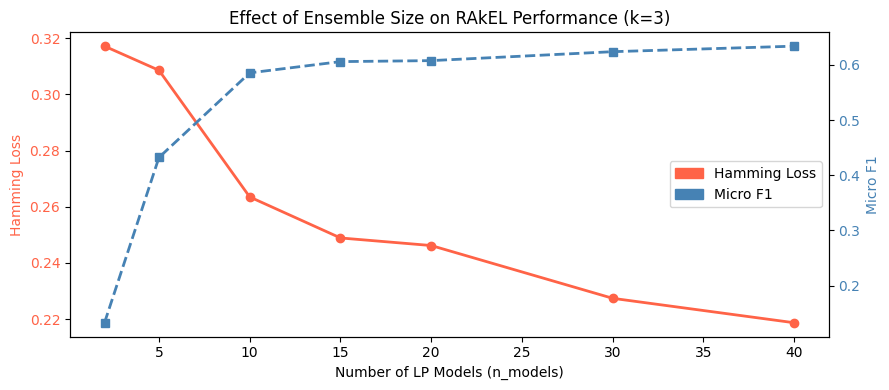

RAkEL + Decision Tree           MicroF1=0.6479  HL=0.1993  t=9.6s
RAkEL + SVM                     MicroF1=0.6640  HL=0.1988  t=10.9s
RAkEL + Logistic Regression     MicroF1=0.6581  HL=0.2004  t=40.0s


,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard,Time (s)
Model,,,,,,,
RAkEL + Decision Tree,0.1993,0.1967,0.6479,0.4356,0.6175,0.5173,9.6100
RAkEL + SVM,0.1988,0.2464,0.6640,0.4044,0.6490,0.5505,10.9300
RAkEL + Logistic Regression,0.2004,0.2526,0.6581,0.4434,0.6371,0.5443,39.9720


In [1]:
# ============================================================
# RAkEL Analysis on GNN Embeddings — YEAST Dataset
# ============================================================
# Loads pre-computed GNN embeddings, then benchmarks RAkEL across:
#   1. Sensitivity to label subset size k
#   2. Effect of ensemble size (n_models)
#   3. Comparison of base classifiers
# ============================================================

import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from time import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, "./../MAIN/")
from applications import RAkEL
from train import evaluate_multilabel

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH   = "/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_embeddings.pkl"
K_DEFAULT  = 3          # label subset size used outside the k-sweep
N_MODELS_DEFAULT = 15   # ensemble size used outside the n_models-sweep
THRESHOLD  = 0.5
RANDOM_STATE = 42

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]          # (N, d)
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]
y         = blob["y"].astype(int)       # (N, C) multi-hot
n_labels  = y.shape[1]

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}  ({n_labels} classes)")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets (train + val → fit, test → evaluate) ───────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train, y_train = H[fit_idx],    y[fit_idx]
X_test,  y_test  = H[test_idx],   y[test_idx]

# ── Helper ────────────────────────────────────────────────────────────────────
def run_rakel(k, n_models, base_clf, X_tr=X_train, y_tr=y_train,
              X_te=X_test, y_te=y_test, mode="overlapping"):
    """Fit a RAkEL model and return (metrics_dict, elapsed_seconds)."""
    model = RAkEL(k=k, n_models=n_models, base_clf=base_clf,
                  mode=mode, threshold=THRESHOLD)
    t0 = time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    elapsed = time() - t0
    metrics = evaluate_multilabel(y_te, y_pred)
    return metrics, elapsed

# ── 3. Sweep k ────────────────────────────────────────────────────────────────
k_range = range(2, min(8, n_labels))
k_results = []

for k in k_range:
    m, t = run_rakel(k, N_MODELS_DEFAULT,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    k_results.append({"k": k, "Hamming Loss": m["Hamming Loss"],
                       "Micro F1": m["Micro F1"], "Time (s)": t})
    print(f"k={k}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}  t={t:.1f}s")

df_k = pd.DataFrame(k_results).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k.index, df_k["Hamming Loss"], "o-", color="tomato",     lw=2)
axes[1].plot(df_k.index, df_k["Micro F1"],     "s-", color="steelblue",  lw=2)
axes[2].bar(df_k.index,  df_k["Time (s)"],          color="mediumseagreen", width=0.6)
for ax, ylabel, title in zip(
    axes,
    ["Hamming Loss", "Micro F1", "Training Time (s)"],
    ["Hamming Loss vs k", "Micro F1 vs k", "Training Time vs k"]
):
    ax.set_xlabel("k (label subset size)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
fig.suptitle(
    f"RAkEL Sensitivity to k  (n_models={N_MODELS_DEFAULT}, overlapping)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── 4. Sweep n_models ─────────────────────────────────────────────────────────
n_model_range = [2, 5, 10, 15, 20, 30, 40]
nm_results = []

for n_m in n_model_range:
    m, _ = run_rakel(K_DEFAULT, n_m,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    nm_results.append({"n_models": n_m, "Hamming Loss": m["Hamming Loss"],
                        "Micro F1": m["Micro F1"]})
    print(f"n_models={n_m:3d}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}")

df_nm = pd.DataFrame(nm_results).set_index("n_models")

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = "tomato", "steelblue"
ax1.plot(df_nm.index, df_nm["Hamming Loss"], "o-", color=color1, lw=2)
ax1.set_xlabel("Number of LP Models (n_models)")
ax1.set_ylabel("Hamming Loss", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(df_nm.index, df_nm["Micro F1"], "s--", color=color2, lw=2)
ax2.set_ylabel("Micro F1", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Effect of Ensemble Size on RAkEL Performance (k={K_DEFAULT})")
plt.legend(
    handles=[mpatches.Patch(color=c, label=l)
             for c, l in [(color1, "Hamming Loss"), (color2, "Micro F1")]],
    loc="center right"
)
plt.tight_layout()
plt.show()

# ── 5. Compare base classifiers ───────────────────────────────────────────────
base_clfs = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM"                : SVC(decision_function_shape="ovo", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
}

clf_results = []
for name, clf in base_clfs.items():
    m, t = run_rakel(k=7, n_models=50, base_clf=clf)
    m["Model"]    = f"RAkEL + {name}"
    m["Time (s)"] = round(t, 3)
    clf_results.append(m)
    print(f"RAkEL + {name:<22s}  MicroF1={m['Micro F1']:.4f}  HL={m['Hamming Loss']:.4f}  t={t:.1f}s")

(
    pd.DataFrame(clf_results)
    .set_index("Model")
    .style
    .background_gradient(subset=["Micro F1", "Sample F1"], cmap="Greens")
    .background_gradient(subset=["Hamming Loss"],           cmap="Reds_r")
    .format(precision=4)
    .set_caption("RAkEL with Different Base Classifiers (k=7, n_models=50)")
)